In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import warnings
from scipy.spatial import cKDTree
from scipy.stats import norm, chi2_contingency, kendalltau
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from itertools import combinations
from prefixspan import PrefixSpan
import seaborn as sns
from sklearn.ensemble import IsolationForest
from scipy.spatial.distance import euclidean
from fastdtw import fastdtw
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split, WeightedRandomSampler

warnings.filterwarnings('ignore')

DATASET_PATH = r'..\Dataset\NHL_Clean_Shots\processed.csv'
GOAL_X = 89
GOAL_Y = 0
NEUTRAL_ZONE_WIDTH = 25
GOAL_WIDTH = 8
CREASE_RADIUS = 6
np.random.seed(42)

df = pd.read_csv(DATASET_PATH)
shots = df[df['eventType'].isin(['shot-on-goal', 'goal', 'missed-shot'])].copy()
shots = shots.dropna(subset=['x_adj', 'y_adj'])
print(f"Loaded {len(shots):,} shot events across {shots['gameId'].nunique():,} games")


Loaded 528,720 shot events across 6,116 games


Moran's I = 0.7295
Expected I under randomness ≈ -0.0015
Permutation p-value = 0.0010

Positive Autocorrelation


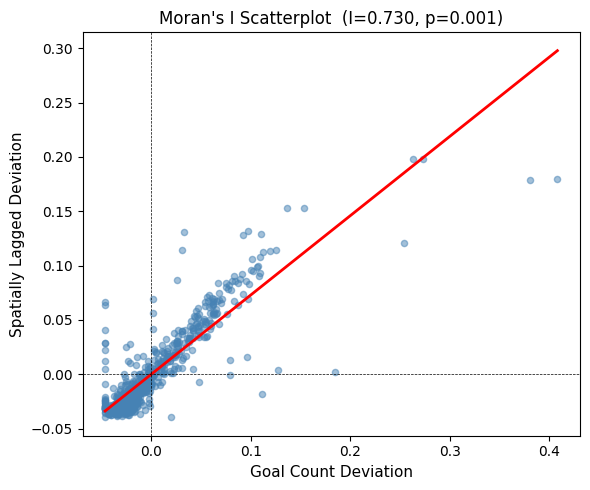

In [37]:
# Rasterise and bin the rink into 30x25 grid cells
# Calculation of moran's I for spatial autocorrelation of goal rates across the rink grid cells allows determination of whether high goal-rate 
# zones cluster together (positive autocorrelation) or alternate with low goal-rate zones (negative autocorrelation), or if the pattern is 
# random (no autocorrelation). This can reveal strategic insights about where on the rink shots are more likely to result in goals and 
# whether these zones are spatially clustered.

x_bins = np.linspace(25, 100, 30)   
y_bins = np.linspace(-42, 42, 25)

shots_off = shots[shots['x_adj'] >= 25].copy()
shots_off['x_bin'] = pd.cut(shots_off['x_adj'], bins=x_bins, labels=False)
shots_off['y_bin'] = pd.cut(shots_off['y_adj'], bins=y_bins, labels=False)

grid_stats = (
    shots_off.groupby(['x_bin', 'y_bin'])
    .agg(n_shots=('is_goal', 'count'), n_goals=('is_goal', 'sum'))
    .reset_index()
)
grid_stats = grid_stats[grid_stats['n_shots'] >= 5]
grid_stats['goal_rate'] = grid_stats['n_goals'] / grid_stats['n_shots']
grid_stats['cx'] = x_bins[grid_stats['x_bin'].astype(int)]
grid_stats['cy'] = y_bins[grid_stats['y_bin'].astype(int)]

coords = grid_stats[['cx', 'cy']].values
z = grid_stats['goal_rate'].values

tree = cKDTree(coords)
k = 8
dists, idxs = tree.query(coords, k=k+1) 

n = len(z)
W = np.zeros((n, n))
for i in range(n):
    neighbors = idxs[i, 1:] 
    W[i, neighbors] = 1

row_sums = W.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
W_std = W / row_sums

z_mean = z.mean()
z_dev = z - z_mean
numerator = (W_std * np.outer(z_dev, z_dev)).sum()
denominator = (z_dev ** 2).sum()
morans_I = (n / W_std.sum()) * (numerator / denominator)

n_perms = 999
perm_I = []
for _ in range(n_perms):
    z_perm = np.random.permutation(z)
    z_dev_p = z_perm - z_perm.mean()
    num_p = (W_std * np.outer(z_dev_p, z_dev_p)).sum()
    den_p = (z_dev_p ** 2).sum()
    perm_I.append((n / W_std.sum()) * (num_p / den_p))

perm_I = np.array(perm_I)
p_value = (np.sum(perm_I >= morans_I) + 1) / (n_perms + 1)

print(f"Moran's I = {morans_I:.4f}")
print(f"Expected I under randomness ≈ {-1/(n-1):.4f}")
print(f"Permutation p-value = {p_value:.4f}")
print()
if p_value < 0.05:
    if morans_I > 0:
        print("Positive Autocorrelation")
    else:
        print("Negative Autocorrelation")
else:
    print("No Significant Autocorrelation")

Wz = W_std @ z_dev
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(z_dev, Wz, alpha=0.5, s=20, color='steelblue')
m, b = np.polyfit(z_dev, Wz, 1)
xs = np.linspace(z_dev.min(), z_dev.max(), 100)
ax.plot(xs, m * xs + b, 'r-', lw=2)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.axvline(0, color='k', lw=0.5, ls='--')
ax.set_xlabel("Goal Count Deviation", fontsize=11)
ax.set_ylabel("Spatially Lagged Deviation", fontsize=11)
ax.set_title(f"Moran's I Scatterplot  (I={morans_I:.3f}, p={p_value:.3f})", fontsize=12)
plt.tight_layout()
plt.show()

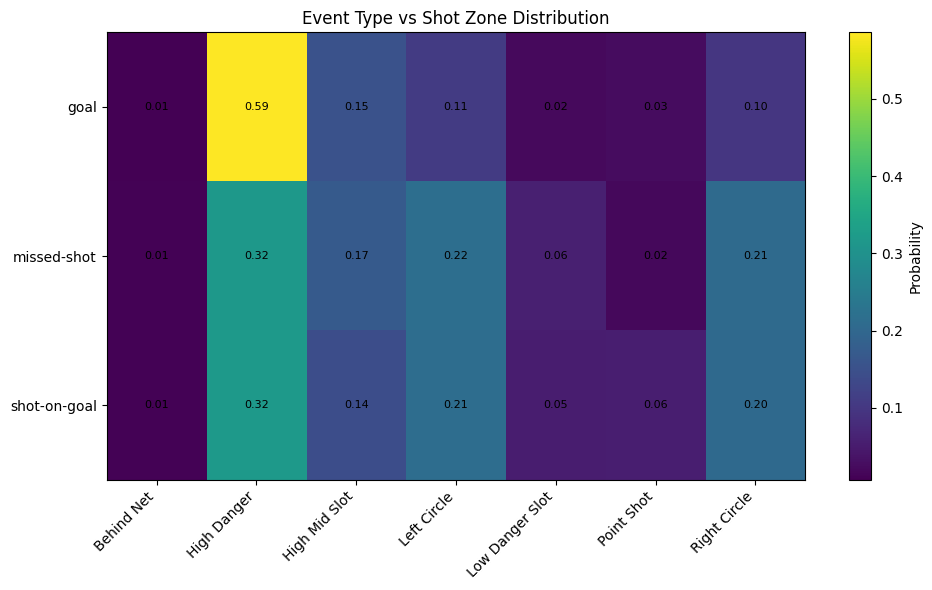

In [38]:
# Identifying eventType-shot_zone relationships, this allows us to check if certain shot zones are more likely to produce specific event types
# through collocation analysis.

zone_cols = [
    'is_behind_net', 'is_high_danger', 'is_low_danger_slot',
    'is_right_circle', 'is_left_circle', 'is_high_mid_slot',
    'is_point_shot', 'is_in_crease'
]

zone_labels = [
    'Behind Net', 'High Danger', 'Low Danger Slot',
    'Right Circle', 'Left Circle', 'High Mid Slot',
    'Point Shot', 'In Crease'
]

df["shot_zone"] = np.select(
    [df[col] == 1 for col in zone_cols],
    zone_labels,
    default="Other"
)

ct = pd.crosstab(df["eventType"], df["shot_zone"], normalize='index')

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(ct.values, aspect='auto')
plt.colorbar(im, ax=ax, label="Probability")
ax.set_xticks(range(len(ct.columns)))
ax.set_yticks(range(len(ct.index)))
ax.set_xticklabels(ct.columns, rotation=45, ha='right')
ax.set_yticklabels(ct.index)
ax.set_title("Event Type vs Shot Zone Distribution")

for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        ax.text(j, i, f"{ct.values[i,j]:.2f}",
                ha='center', va='center',
                fontsize=8)

plt.tight_layout()
plt.show()

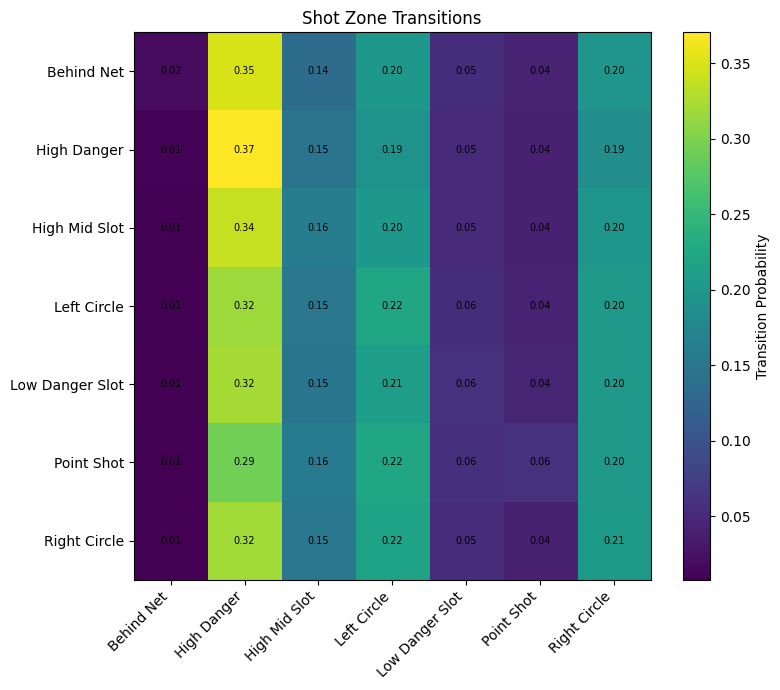

In [39]:
# Identifying how players and shots transition between zones as games progress, this can reveal common shot sequences and player movement 
# patterns that lead to goals or high-danger shots. By analyzing these transitions, we can identify key zones that players frequently move 
# through before taking shots, which can inform coaching strategies and player development.

df = df.sort_values(["gameId", "period", "game_seconds"])
df["prev_zone"] = df.groupby("gameId")["shot_zone"].shift(1)
trans_df = df.dropna(subset=["prev_zone", "shot_zone"])

transition = pd.crosstab(
    trans_df["prev_zone"],
    trans_df["shot_zone"],
    normalize='index'
)

# Rows = previous zone, Columns = current zone, Values = probability of transitioning from previous to current zone
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(transition.values, aspect='auto')
plt.colorbar(im, ax=ax, label="Transition Probability")
ax.set_xticks(range(len(transition.columns)))
ax.set_yticks(range(len(transition.index)))
ax.set_xticklabels(transition.columns, rotation=45, ha='right')
ax.set_yticklabels(transition.index)
ax.set_title("Shot Zone Transitions")

for i in range(transition.shape[0]):
    for j in range(transition.shape[1]):
        ax.text(j, i, f"{transition.values[i,j]:.2f}",
                ha='center', va='center',
                fontsize=7)

plt.tight_layout()
plt.show()

Goals: 1 clusters, noise ratio=0.176
Non-Goals: 5 clusters, noise ratio=0.450


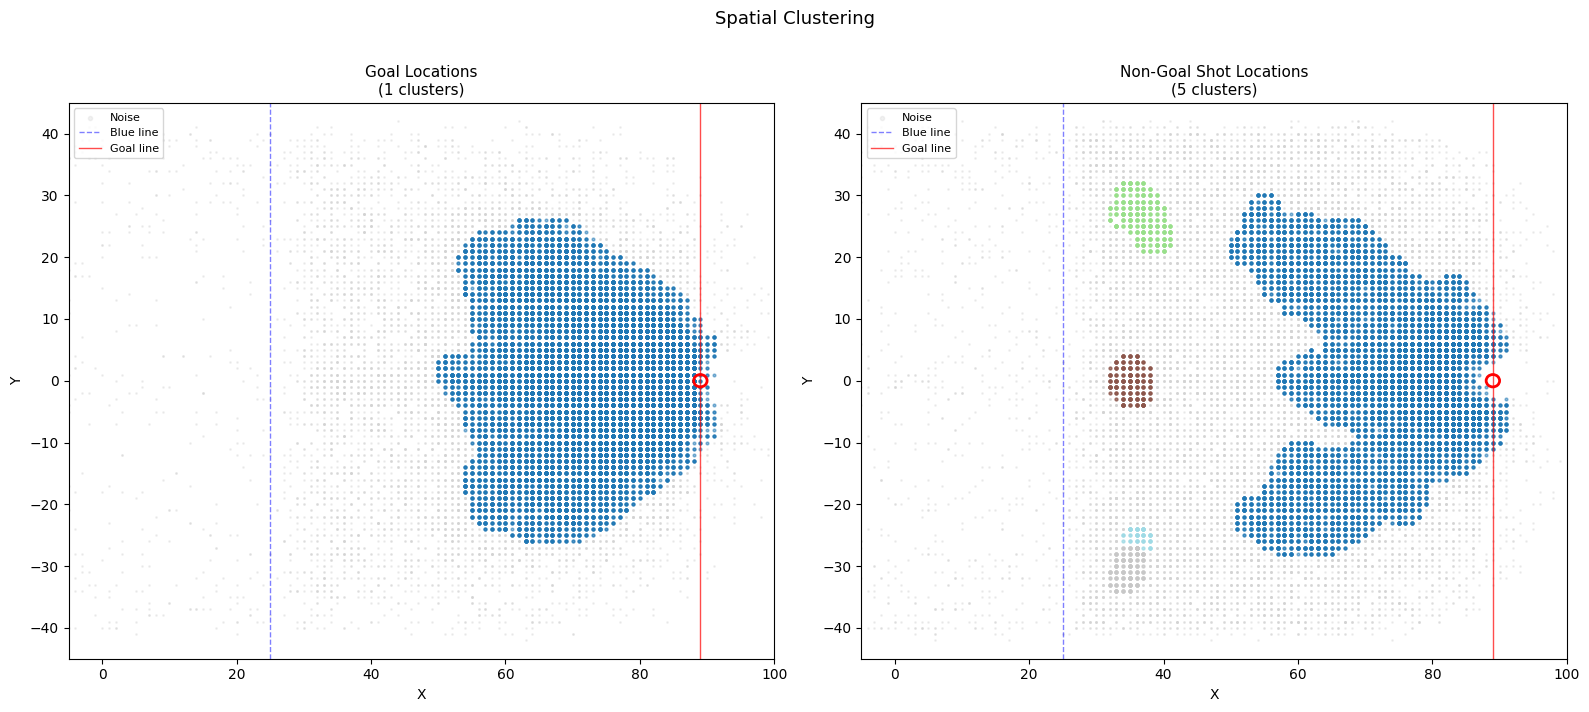

In [40]:
# Spatial clustering of shot locations using DBSCAN allows us to identify natural groupings of where shots are taken on the rink, and 
# whether these clusters differ between goals and non-goals. This can reveal high-density shooting areas and potential "hot zones" 
# for scoring. This allows visual interpretation of the results that generate moran's scatterplot and collocation heatmaps.

goals_df   = shots[shots['is_goal'] == 1][['x_adj', 'y_adj']].dropna()
non_goal_df = shots[shots['is_goal'] == 0][['x_adj', 'y_adj']].dropna().sample(n=min(30000, len(shots)), random_state=42)

def run_dbscan(coords, eps=3.5, min_samples=30, label=''):
    db = DBSCAN(eps=eps, min_samples=min_samples, algorithm='ball_tree', metric='euclidean')
    labels = db.fit_predict(coords)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = (labels == -1).mean()
    print(f"{label}: {n_clusters} clusters, noise ratio={noise_ratio:.3f}")
    return labels, n_clusters

goal_coords = goals_df.values
ng_coords   = non_goal_df.values

goal_labels, n_gclusters = run_dbscan(goal_coords, eps=2.5, min_samples=150, label='Goals')
ng_labels, n_ngclusters = run_dbscan(ng_coords, eps=2.5, min_samples=150, label='Non-Goals')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, coords, labels, n_clusters, title in [
    (axes[0], goal_coords, goal_labels, n_gclusters, 'Goal Locations'),
    (axes[1], ng_coords, ng_labels, n_ngclusters, 'Non-Goal Shot Locations')
]:
    unique_labels = set(labels)
    cmap = plt.cm.get_cmap('tab20', n_clusters)
    for k in unique_labels:
        mask = labels == k
        if k == -1:
            ax.scatter(coords[mask, 0], coords[mask, 1], c='lightgrey', s=1, alpha=0.3, label='Noise')
        else:
            ax.scatter(coords[mask, 0], coords[mask, 1], c=[cmap(k)], s=4, alpha=0.5)
    
    # Draw rink lines
    ax.axvline(x=25,  color='blue',   lw=1, ls='--', alpha=0.5, label='Blue line')
    ax.axvline(x=89,  color='red',    lw=1, ls='-',  alpha=0.7, label='Goal line')
    goal_post = plt.Circle((89, 0), radius=1, color='red', fill=False, lw=2)
    ax.add_patch(goal_post)
    ax.set_xlim(-5, 100)
    ax.set_ylim(-45, 45)
    ax.set_xlabel('X', fontsize=10)
    ax.set_ylabel('Y', fontsize=10)
    ax.set_title(f'{title}\n({n_clusters} clusters)', fontsize=11)
    ax.legend(loc='upper left', fontsize=8, markerscale=3)

plt.suptitle("Spatial Clustering", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

goals_df['cluster'] = goal_labels
cluster_stats = (
    goals_df[goals_df['cluster'] >= 0]
    .groupby('cluster')
    .agg(count=('x_adj', 'count'),
         cx=('x_adj', 'mean'),
         cy=('y_adj', 'mean'))
    .sort_values('count', ascending=False)
)

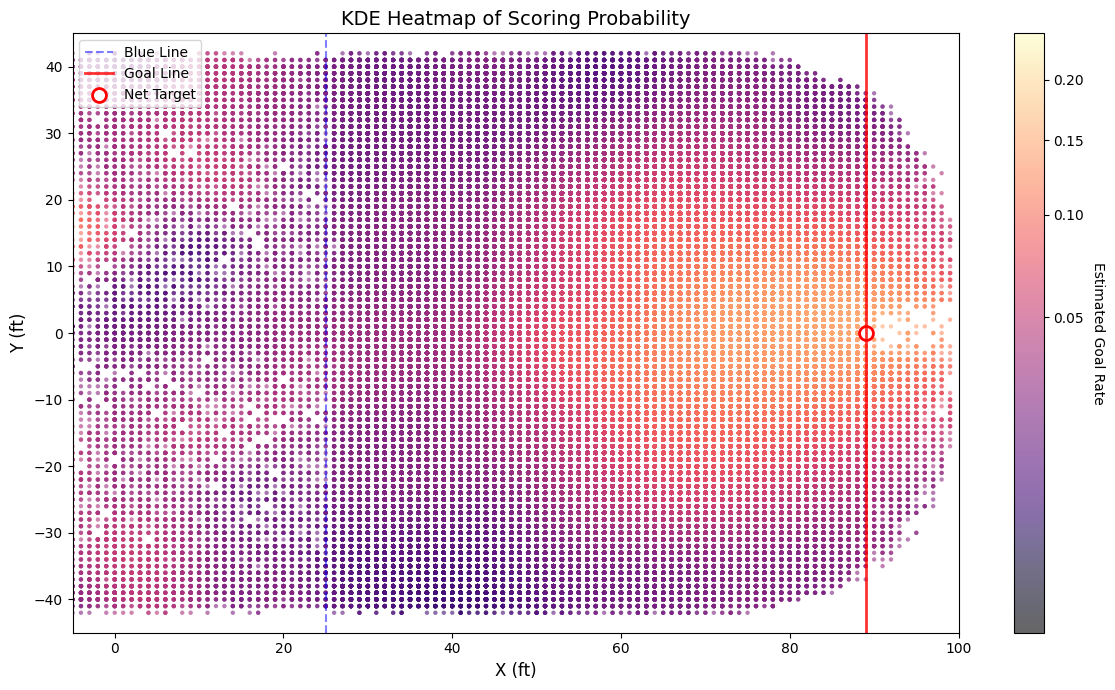

In [41]:
# Create a KDE heatmap of shot locations, colored by goal rate (KDE intensity), this allows us to visually identify "hot zones" on the 
# rink where shots are more likely to result in goals,

import matplotlib.colors


plt.figure(figsize=(12, 7))
sc = plt.scatter(
    shots['x_adj'], 
    shots['y_adj'], 
    c=shots['kde_goal_rate'], 
    cmap='magma', 
    s=10, 
    alpha=0.6,
    edgecolors='none',
    norm = matplotlib.colors.PowerNorm(gamma=0.4)
)

cbar = plt.colorbar(sc)
cbar.set_label('Estimated Goal Rate', rotation=270, labelpad=15)

plt.axvline(x=25, color='blue', lw=1.5, ls='--', alpha=0.5, label='Blue Line')
plt.axvline(x=89, color='red', lw=2, ls='-', alpha=0.8, label='Goal Line')
plt.scatter(89, 0, color='white', edgecolors='red', s=100, lw=2, label='Net Target')

plt.xlim(-5, 100)
plt.ylim(-45, 45)
plt.title('KDE Heatmap of Scoring Probability', fontsize=14)
plt.xlabel('X (ft)', fontsize=12)
plt.ylabel('Y (ft)', fontsize=12)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

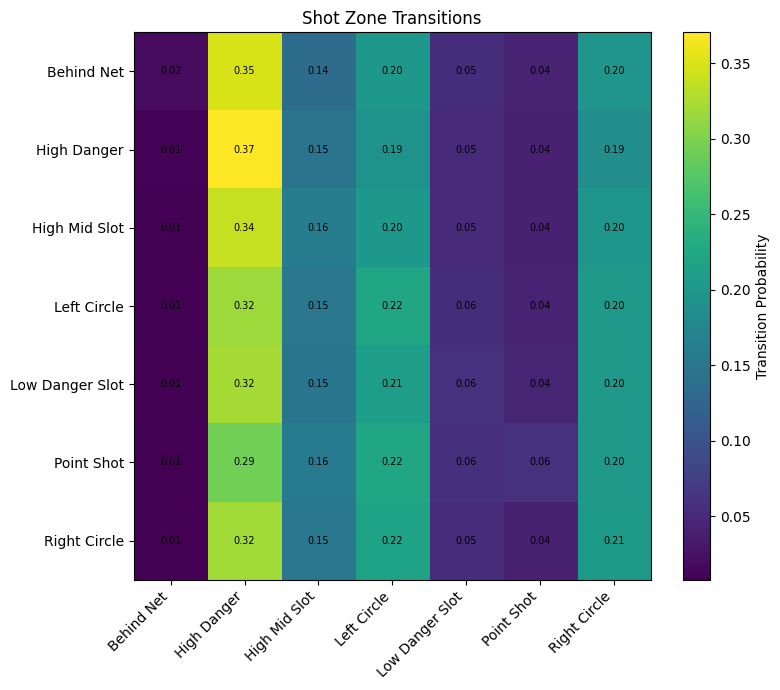

In [42]:
# Identifying how players and shots transition between zones as games progress, this can reveal common shot sequences and player movement 
# patterns that lead to goals or high-danger shots. By analyzing these transitions, we can identify key zones that players frequently move 
# through before taking shots, which can inform coaching strategies and player development.

df = df.sort_values(["gameId", "period", "game_seconds"])
df["prev_zone"] = df.groupby("gameId")["shot_zone"].shift(1)
trans_df = df.dropna(subset=["prev_zone", "shot_zone"])

transition = pd.crosstab(
    trans_df["prev_zone"],
    trans_df["shot_zone"],
    normalize='index'
)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(transition.values, aspect='auto')
plt.colorbar(im, ax=ax, label="Transition Probability")
ax.set_xticks(range(len(transition.columns)))
ax.set_yticks(range(len(transition.index)))
ax.set_xticklabels(transition.columns, rotation=45, ha='right')
ax.set_yticklabels(transition.index)
ax.set_title("Shot Zone Transitions")

for i in range(transition.shape[0]):
    for j in range(transition.shape[1]):
        ax.text(j, i, f"{transition.values[i,j]:.2f}",
                ha='center', va='center',
                fontsize=7)

plt.tight_layout()
plt.show()

Detected 5288 spatial anomalies (unusual shot locations).


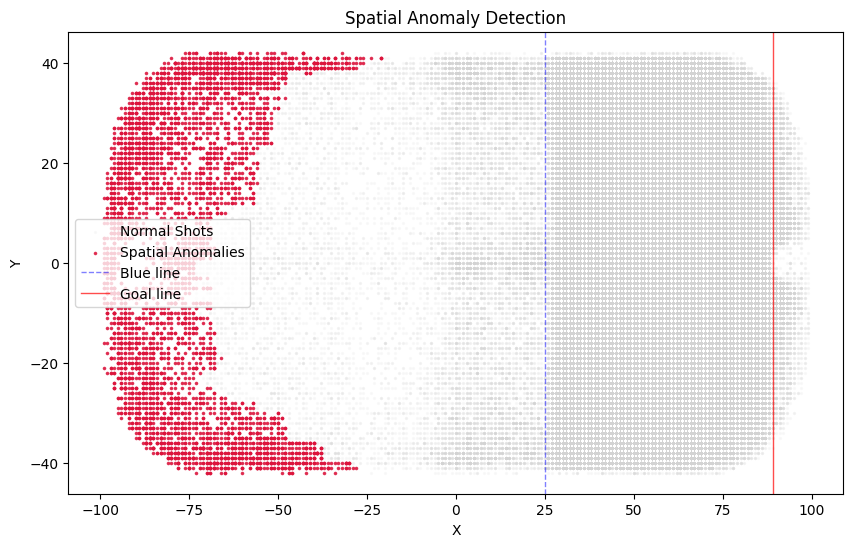

In [47]:
# Identifying spatial anomalies in shot locations using Isolation Forest allows us to detect shots taken from unusual locations on the rink 
# that deviate

spatial_data = shots[['x_adj', 'y_adj']].dropna()

iso_forest = IsolationForest(contamination=0.01, random_state=42)
outlier_labels = iso_forest.fit_predict(spatial_data)
shots.loc[spatial_data.index, 'spatial_anomaly'] = outlier_labels
spatial_anomalies = shots[shots['spatial_anomaly'] == -1]

print(f"Detected {len(spatial_anomalies)} spatial anomalies (unusual shot locations).")

plt.figure(figsize=(10, 6))
plt.scatter(shots['x_adj'], shots['y_adj'], c='lightgrey', s=2, alpha=0.1, label='Normal Shots')
plt.scatter(spatial_anomalies['x_adj'], spatial_anomalies['y_adj'], c='crimson', s=2.5, alpha=0.8, label='Spatial Anomalies')

plt.axvline(x=25, color='blue', lw=1, ls='--', alpha=0.5, label='Blue line')
plt.axvline(x=89, color='red', lw=1, ls='-', alpha=0.7, label='Goal line')

plt.title('Spatial Anomaly Detection')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

In [44]:
# Finding recurring patterns through the lagged event sequences using the PrefixSpan algorithm for sequential pattern mining.
game_sequences = (
    df.groupby("gameId")["eventType"]
    .apply(list)
    .reset_index(drop=True)
    .tolist()
)

windowed_sequences = []
for seq in game_sequences:
    for i in range(0, len(seq) - 10, 5):
        windowed_sequences.append(seq[i:i+10])

min_sup = int(0.3 * len(game_sequences))
ps = PrefixSpan(windowed_sequences)
frequent_patterns = ps.topk(50)

frequent_patterns_df = pd.DataFrame(frequent_patterns, columns=["support", "pattern"])
frequent_patterns_df["length"] = frequent_patterns_df["pattern"].apply(len)
frequent_patterns_df["support_pct"] = frequent_patterns_df["support"] / len(windowed_sequences)

print(
    frequent_patterns_df
    .query("length >= 2")
    .sort_values("support", ascending=False)
    .head(20)
    .to_string(index=False)
)

 support                                                                              pattern  length  support_pct
   95857                                                         [shot-on-goal, shot-on-goal]       2     0.998968
   95229                                           [shot-on-goal, shot-on-goal, shot-on-goal]       3     0.992424
   92512                             [shot-on-goal, shot-on-goal, shot-on-goal, shot-on-goal]       4     0.964109
   89832                                                          [shot-on-goal, missed-shot]       2     0.936179
   89765                                                          [missed-shot, shot-on-goal]       2     0.935481
   85119                                            [shot-on-goal, shot-on-goal, missed-shot]       3     0.887063
   85069                                            [missed-shot, shot-on-goal, shot-on-goal]       3     0.886542
   84895                                            [shot-on-goal, missed-shot, 

Detected 20816 anomalous offensive flurries

            gameId  game_minute  event_count  z_score_global
182018  2023020442           80           24       21.364937
262620  2024020883           80           20       17.502715
98193   2021021263           80           18       15.571603
225950  2024020081           80           18       15.571603
162904  2023020032           80           18       15.571603
55220   2021020340           80           18       15.571603
151694  2022021102           80           18       15.571603
201720  2023020867           80           17       14.606048
183486  2023020473           80           17       14.606048
83893   2021020956           80           16       13.640492


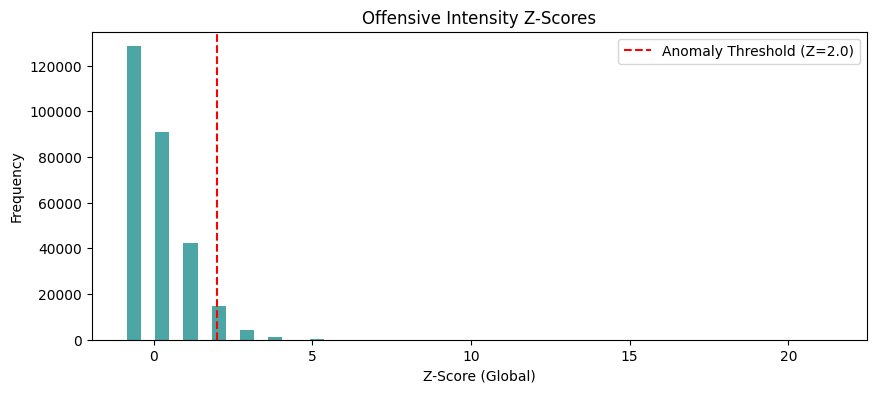

In [52]:
df['game_minute'] = (df['game_seconds'] // 60).astype(int)
activity_series = df.groupby(['gameId', 'game_minute']).size().reset_index(name='event_count')

global_mean = activity_series['event_count'].mean()
global_std  = activity_series['event_count'].std()

activity_series['z_score_global'] = (activity_series['event_count'] - global_mean) / global_std

threshold = 2.0
anomalies = activity_series[activity_series['z_score_global'] > threshold].copy()

print(f"Detected {len(anomalies)} anomalous offensive flurries\n")
print(anomalies.sort_values('event_count', ascending=False).head(10))

plt.figure(figsize=(10, 4))
plt.hist(activity_series['z_score_global'], bins=50, color='teal', alpha=0.7)
plt.axvline(threshold, color='red', linestyle='--', label=f'Anomaly Threshold (Z={threshold})')
plt.title('Offensive Intensity Z-Scores')
plt.xlabel('Z-Score (Global)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

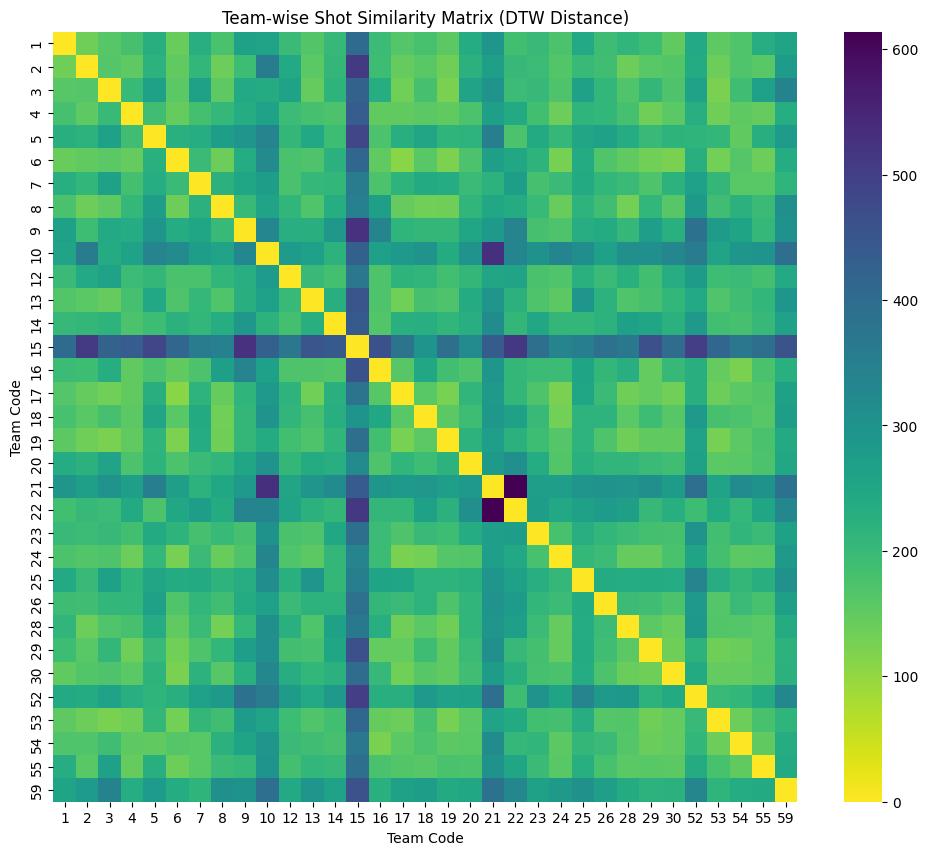

The most similar offensive profiles are 6 and 17 (Distance: 109.60)


In [58]:
df['event_idx'] = df.groupby(['gameId', 'eventOwnerTeamId']).cumcount()

team_profiles = df.groupby(['eventOwnerTeamId', 'event_idx'])['shot_distance'].mean().unstack()
team_sequences = {team: team_profiles.loc[team].dropna().values.reshape(-1, 1) 
                  for team in team_profiles.index}

teams = list(team_sequences.keys())
n_teams = len(teams)
dist_matrix = np.zeros((n_teams, n_teams))

for i in range(n_teams):
    for j in range(i + 1, n_teams):
        dist, _ = fastdtw(team_sequences[teams[i]], team_sequences[teams[j]], dist=euclidean)
        dist_matrix[i, j] = dist
        dist_matrix[j, i] = dist 

dtw_df = pd.DataFrame(dist_matrix, index=teams, columns=teams)

plt.figure(figsize=(12, 10))
sns.heatmap(dtw_df, cmap='viridis_r', annot=False)
plt.title('Team-wise Shot Similarity Matrix (DTW Distance)')
plt.xlabel('Team Code')
plt.ylabel('Team Code')
plt.show()

min_dist = dtw_df[dtw_df > 0].min().min()
pair = np.where(dtw_df == min_dist)
team1, team2 = teams[pair[0][0]], teams[pair[0][1]]

print(f"The most similar offensive profiles are {team1} and {team2} (Distance: {min_dist:.2f})")

In [70]:
N, T, F = X_seq.shape
X_flat = X_seq.reshape(-1, F)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat).reshape(N, T, F)

X_t = torch.tensor(X_scaled, dtype=torch.float32)
y_t = torch.tensor(y_seq[:, -1], dtype=torch.float32) 

dataset = TensorDataset(X_t, y_t)
n_train = int(0.8 * len(dataset))
n_val = len(dataset) - n_train
train_ds, val_ds = random_split(dataset, [n_train, n_val], generator=torch.Generator().manual_seed(42))

game_has_goal = (y_seq.sum(axis=1) > 0).astype(int)
game_weights = 1. / np.bincount(game_has_goal)
sample_weights = game_weights[game_has_goal]
train_weights = sample_weights[train_ds.indices]

sampler = WeightedRandomSampler(train_weights, len(train_weights))
train_dl = DataLoader(train_ds, batch_size=128, sampler=sampler) 
val_dl = DataLoader(val_ds, batch_size=256)

class ShotLSTM(nn.Module):
    def __init__(self, input_size, hidden=128, layers=2, dropout=0.4):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, num_layers=layers, 
                            batch_first=True, dropout=dropout, bidirectional=False)
        self.head = nn.Sequential(
            nn.Linear(hidden, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = torch.mean(out, dim=1) 
        return self.head(out).squeeze(-1)
    
device = "cuda" if torch.cuda.is_available() else "cpu"
model_lstm = ShotLSTM(input_size=F).to(device)

model_lstm.load_state_dict(torch.load("shot_lstm_model.pth", map_location=device))

model_lstm.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for Xb, yb in val_dl:
        Xb = Xb.to(device)
        logits = model_lstm(Xb)
        probs = torch.sigmoid(logits)
        
        all_preds.extend(probs.cpu().numpy().ravel())
        all_targets.extend(yb.numpy().ravel())

In [80]:
shots = df[df['eventType'].isin(['shot-on-goal', 'goal', 'missed-shot'])].copy()
shots = shots.dropna(subset=['x_adj', 'y_adj', 'kde_goal_rate'])

y_spatial = shots['is_goal'].values
kde_scores = shots['kde_goal_rate'].values

from sklearn.model_selection import train_test_split
_, shots_test, _, y_spatial_test, _, kde_test = train_test_split(
    shots, y_spatial, kde_scores,
    test_size=0.2, random_state=42, stratify=y_spatial
)

lstm_preds   = np.array(all_preds)
lstm_targets = np.array(all_targets)

fpr_kde,  tpr_kde,  _ = roc_curve(y_spatial_test, kde_test)
fpr_lstm, tpr_lstm, _ = roc_curve(lstm_targets,   lstm_preds)

auc_kde  = auc(fpr_kde,  tpr_kde)
auc_lstm = auc(fpr_lstm, tpr_lstm)

prec_kde,  rec_kde,  _ = precision_recall_curve(y_spatial_test, kde_test)
prec_lstm, rec_lstm, _ = precision_recall_curve(lstm_targets,   lstm_preds)

ap_kde  = average_precision_score(y_spatial_test, kde_test)
ap_lstm = average_precision_score(lstm_targets,   lstm_preds)


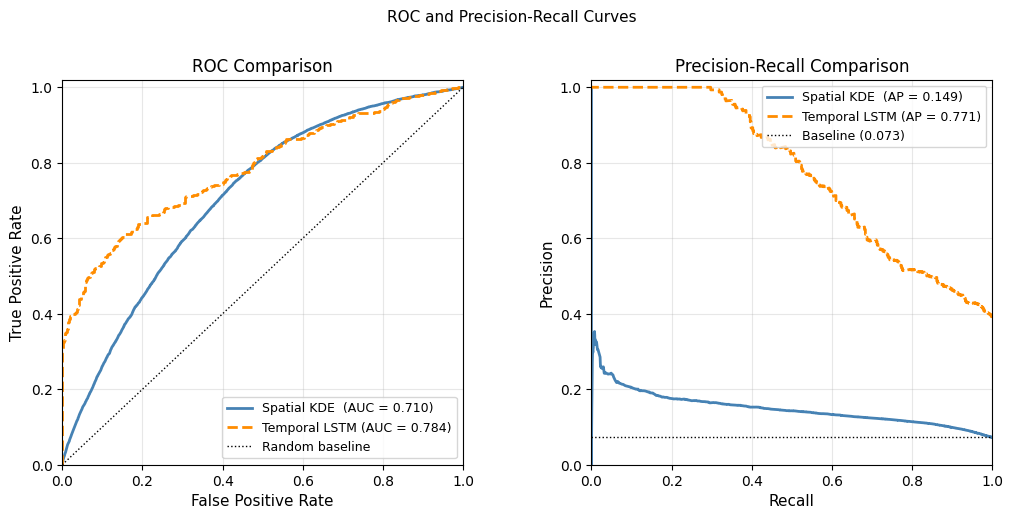

In [ ]:
fig = plt.figure(figsize=(12, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.32)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(fpr_kde,  tpr_kde,  color='steelblue', lw=2,
         label=f'Spatial KDE  (AUC = {auc_kde:.3f})')
ax1.plot(fpr_lstm, tpr_lstm, color='darkorange', lw=2, linestyle='--',
         label=f'Temporal LSTM (AUC = {auc_lstm:.3f})')
ax1.plot([0, 1], [0, 1], 'k:', lw=1, label='Random baseline')
ax1.set_xlabel('False Positive Rate', fontsize=11)
ax1.set_ylabel('True Positive Rate',  fontsize=11)
ax1.set_title('ROC Comparison', fontsize=12)
ax1.legend(fontsize=9, loc='lower right')
ax1.set_xlim([0, 1]); ax1.set_ylim([0, 1.02])
ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(rec_kde,  prec_kde,  color='steelblue', lw=2,
         label=f'Spatial KDE  (AP = {ap_kde:.3f})')
ax2.plot(rec_lstm, prec_lstm, color='darkorange', lw=2, linestyle='--',
         label=f'Temporal LSTM (AP = {ap_lstm:.3f})')
baseline_rate = y_spatial_test.mean()
ax2.axhline(baseline_rate, color='k', lw=1, linestyle=':', label=f'Baseline ({baseline_rate:.3f})')
ax2.set_xlabel('Recall',    fontsize=11)
ax2.set_ylabel('Precision', fontsize=11)
ax2.set_title('Precision-Recall Comparison', fontsize=12)
ax2.legend(fontsize=9, loc='upper right')
ax2.set_xlim([0, 1]); ax2.set_ylim([0, 1.02])
ax2.grid(alpha=0.3)

plt.suptitle('ROC and Precision-Recall Curves', fontsize=11, y=1.02)
plt.show()